DATASET OVERVIEW
Dataset Shape: (1800, 11)

First 5 rows of the dataset:

DATASET INFORMATION

Column names and data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               1800 non-null   int64  
 1   day_type              1800 non-null   object 
 2   work_hours            1800 non-null   float64
 3   screen_time_hours     1800 non-null   float64
 4   meetings_count        1800 non-null   int64  
 5   breaks_taken          1800 non-null   int64  
 6   after_hours_work      1800 non-null   int64  
 7   sleep_hours           1800 non-null   float64
 8   task_completion_rate  1800 non-null   float64
 9   burnout_score         1800 non-null   float64
 10  burnout_risk          1800 non-null   object 
dtypes: float64(5), int64(4), object(2)
memory usage: 154.8+ KB

STATISTICAL SUMMARY

Numerical columns st

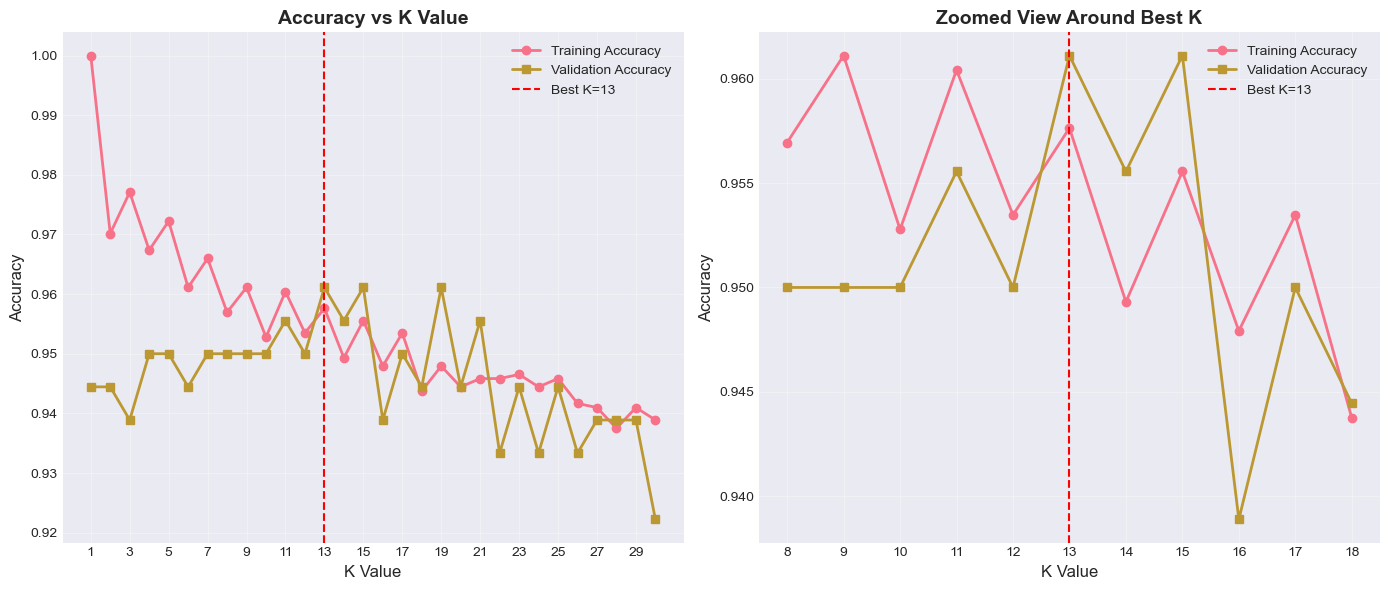

GRID SEARCH WITH CROSS-VALIDATION
Fitting 5 folds for each of 84 candidates, totalling 420 fits

Best parameters: {'metric': 'manhattan', 'n_neighbors': 7, 'p': 1, 'weights': 'distance'}
Best cross-validation accuracy: 0.9642

Top 5 configurations:
                                               params  mean_test_score  \
37  {'metric': 'manhattan', 'n_neighbors': 7, 'p':...         0.964198   
39  {'metric': 'manhattan', 'n_neighbors': 7, 'p':...         0.964198   
65  {'metric': 'minkowski', 'n_neighbors': 7, 'p':...         0.964198   
28  {'metric': 'manhattan', 'n_neighbors': 3, 'p':...         0.963580   
29  {'metric': 'manhattan', 'n_neighbors': 3, 'p':...         0.963580   

    std_test_score  
37        0.006355  
39        0.006355  
65        0.006355  
28        0.007407  
29        0.007407  
FINAL MODEL EVALUATION

Test Set Performance:
Accuracy:  0.9556
Precision: 0.9437
Recall:    0.9556
F1 Score:  0.9493

CLASSIFICATION REPORT (Test Set)
              precision    r

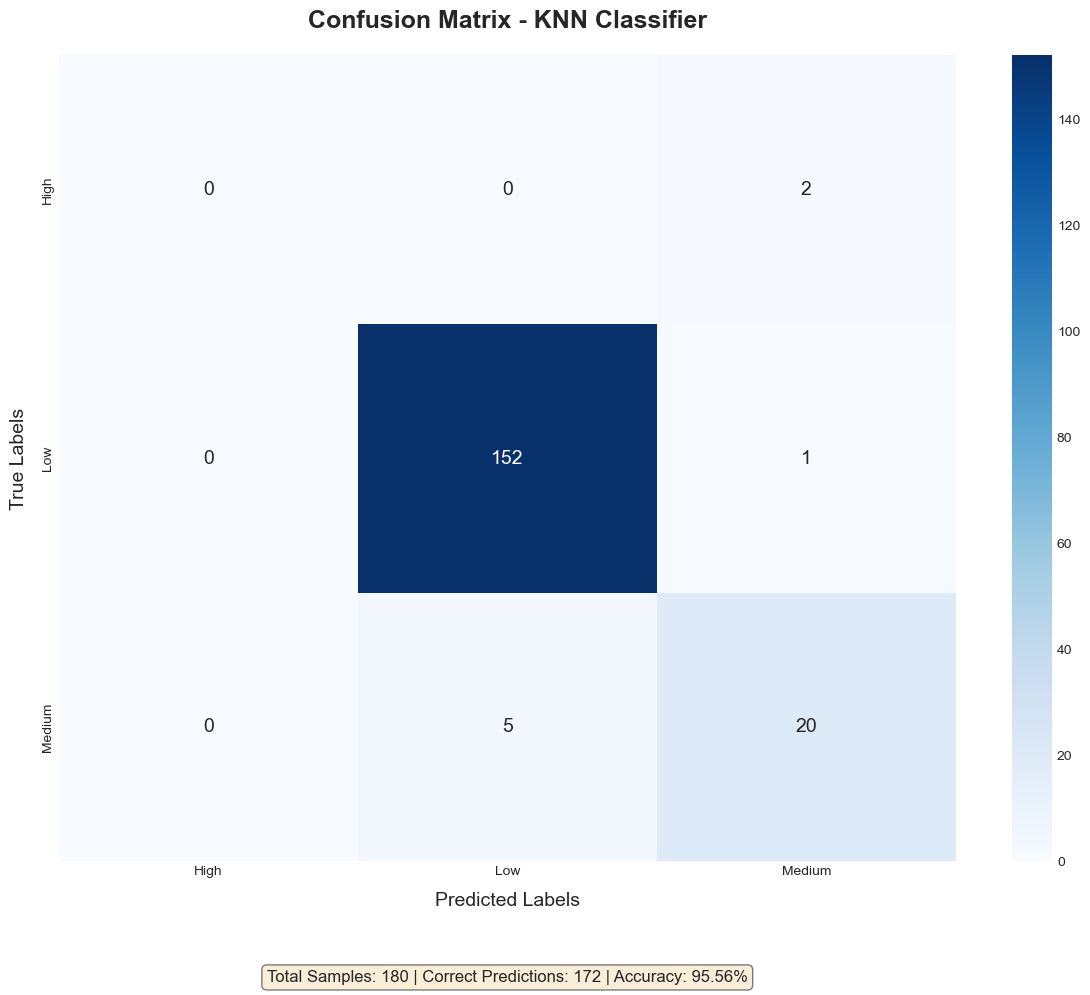

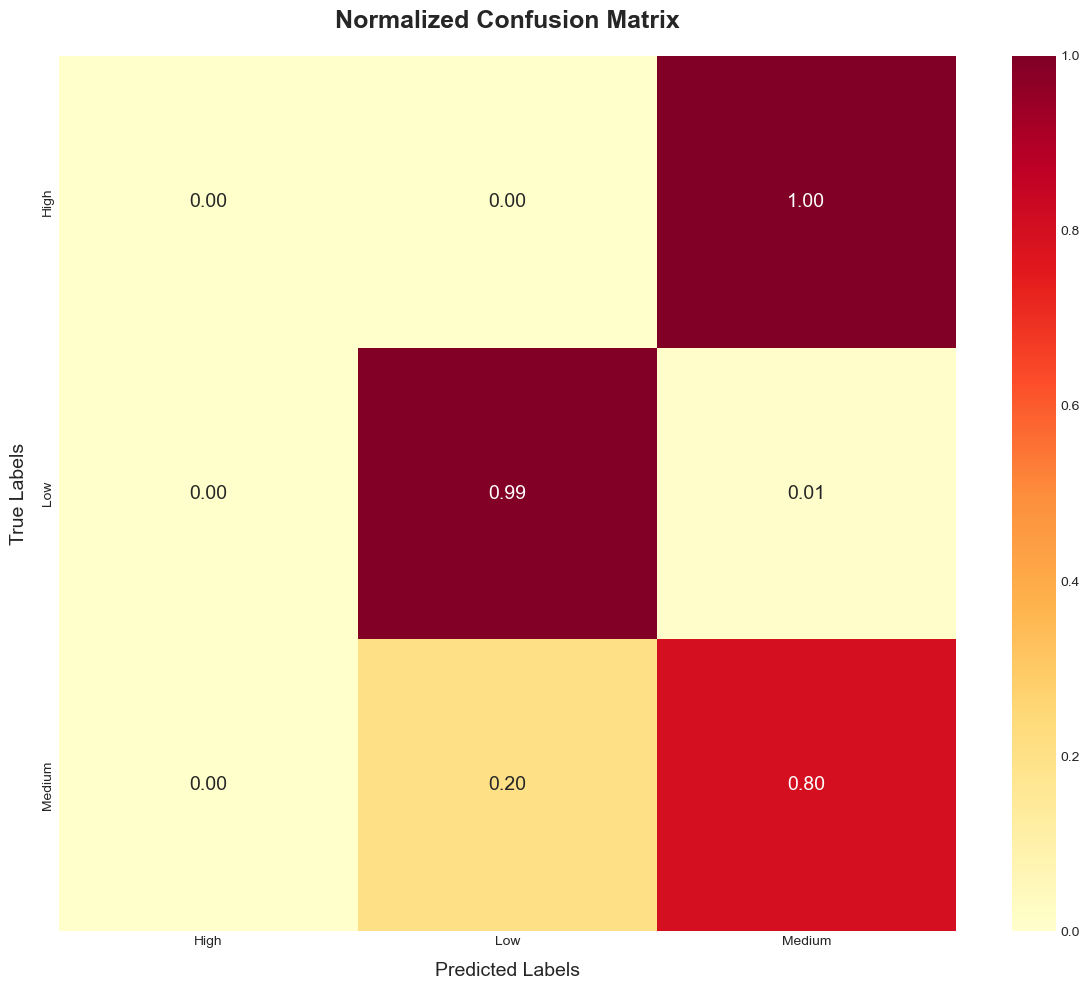

PER-CLASS PERFORMANCE ANALYSIS

Class: High
  Precision:  0.0000
  Recall:     0.0000
  F1-Score:   0.0000
  Specificity:1.0000
  Support:    2

Class: Low
  Precision:  0.9682
  Recall:     0.9935
  F1-Score:   0.9806
  Specificity:0.8148
  Support:    153

Class: Medium
  Precision:  0.8696
  Recall:     0.8000
  F1-Score:   0.8333
  Specificity:0.9806
  Support:    25


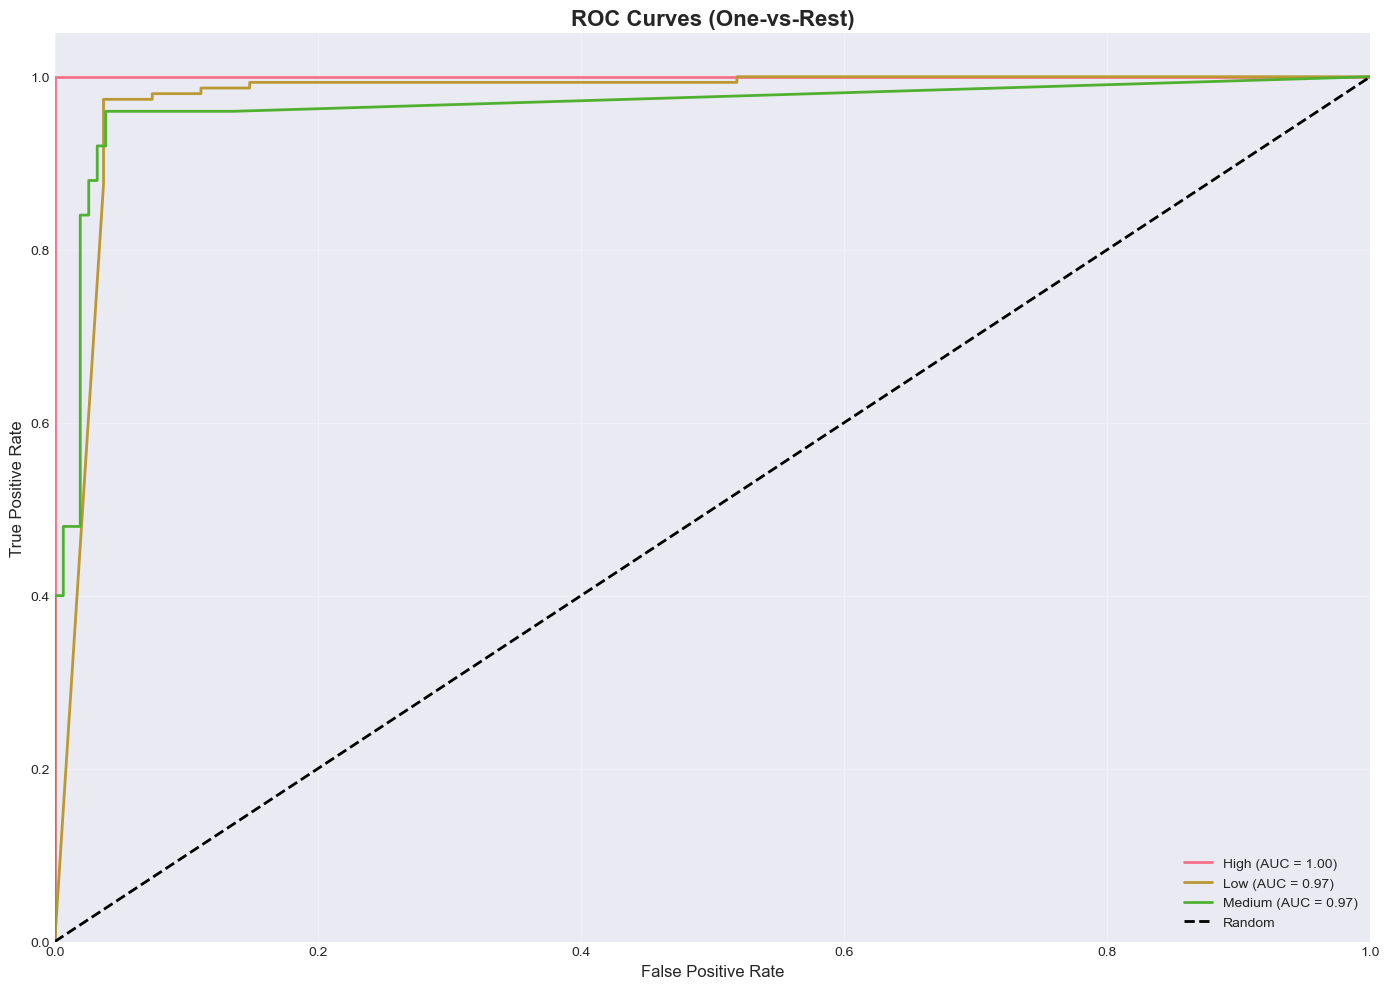

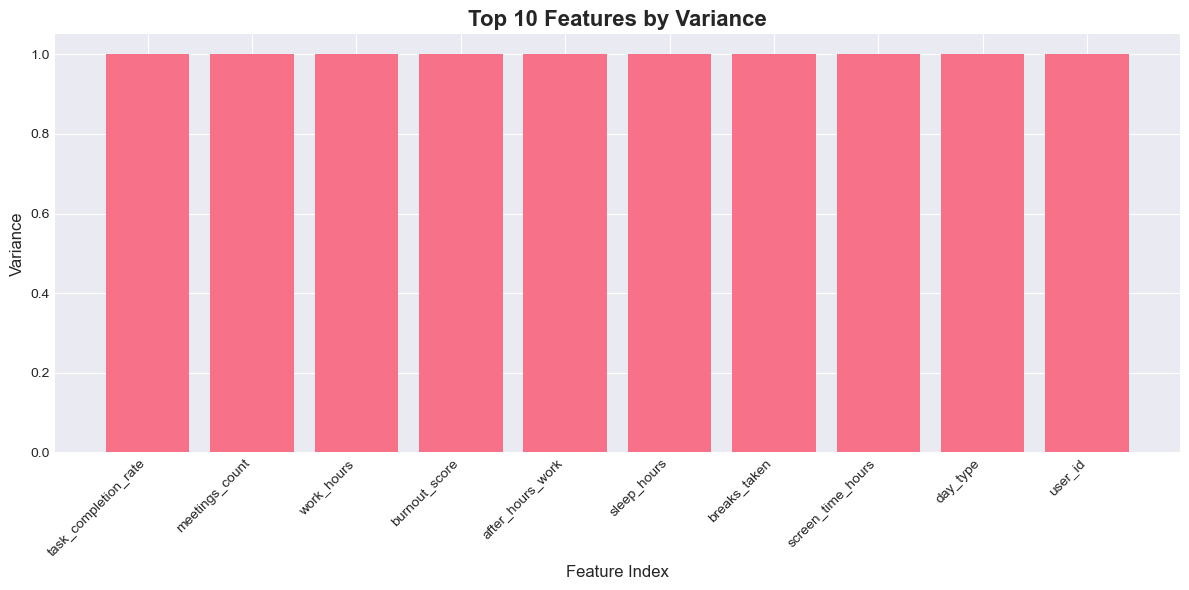

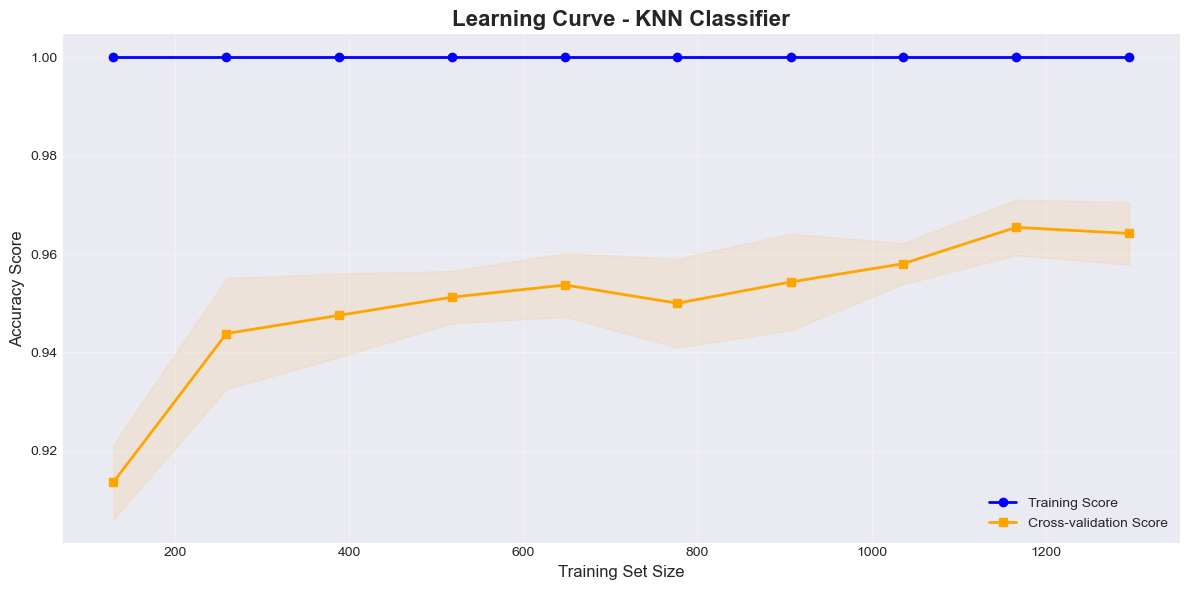


Model Comparison Results:
 Configuration  Accuracy  Precision   Recall  F1-Score
K=3, Euclidean  0.938889   0.926118 0.938889  0.931867
K=5, Euclidean  0.950000   0.937777 0.950000  0.943228
K=7, Euclidean  0.950000   0.937777 0.950000  0.943228
K=5, Manhattan  0.955556   0.949041 0.955556  0.952025
 K=5, Weighted  0.950000   0.937777 0.950000  0.943228


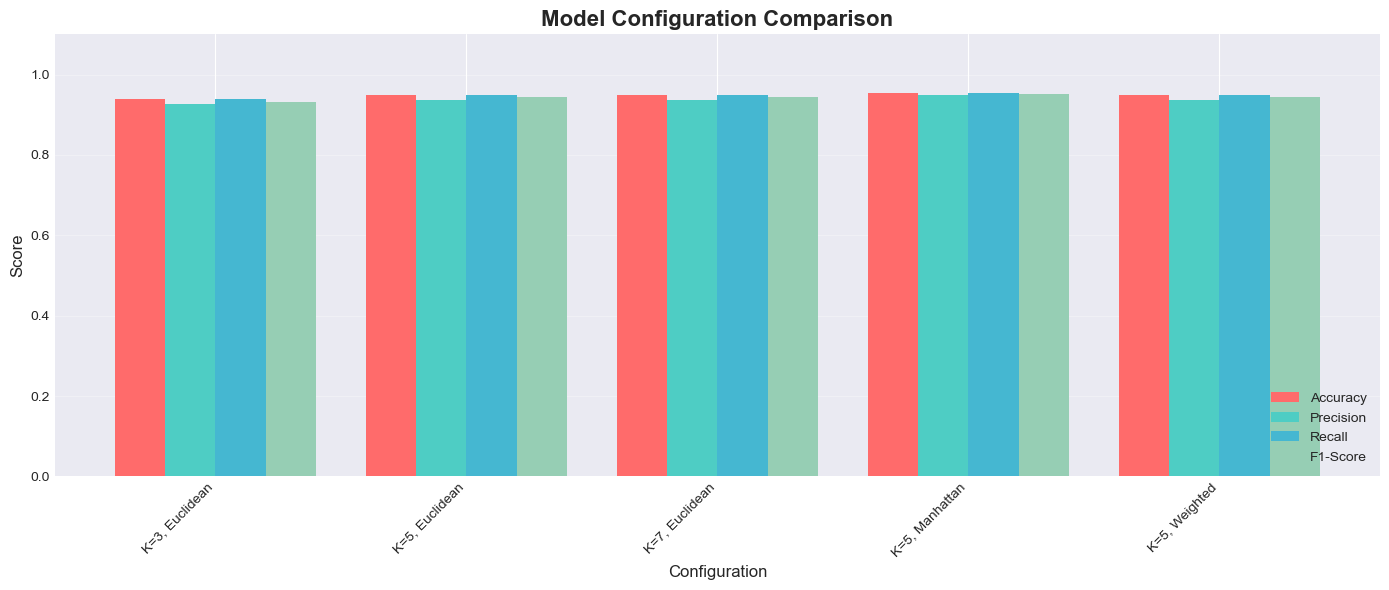


FINAL SUMMARY AND CONCLUSIONS

DATASET SUMMARY:
--------------- 
Total samples: 1800
Number of features: 10
Number of classes: 3
Class distribution (encoded): 
{0: 20, 1: 1527, 2: 253}

BEST MODEL CONFIGURATION:
------------------------
Algorithm: K-Nearest Neighbors (scikit-learn)
Best parameters: {'metric': 'manhattan', 'n_neighbors': 7, 'p': 1, 'weights': 'distance'}
Number of neighbors (k): 7
Distance metric: manhattan
Weights: distance

PERFORMANCE METRICS (Test Set):
------------------------------
Accuracy:  0.9556 (95.56%)
Precision: 0.9437
Recall:    0.9556
F1-Score:  0.9493

KEY FINDINGS:
------------
1. Optimal K value: 13 (found through validation and grid search)
2. Best distance metric: manhattan
3. Model generalizes well 
   (Validation vs Test difference: 0.0056)
4. Performance varies across classes

CONCLUSION:
----------
The KNN model implemented using scikit-learn successfully classifies student productivity 
with 95.56% accuracy. The model performs well 
on the test

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, recall_score, f1_score, 
                           confusion_matrix, classification_report,
                           precision_score, roc_curve, auc)
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# 2. Load and Explore the Dataset


df = pd.read_csv('work_from_home_burnout_dataset.csv')


print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Dataset Shape: {df.shape}")
print(f"\nFirst 5 rows of the dataset:")
df.head()


# Get dataset information
print("\n" + "="*60)
print("DATASET INFORMATION")
print("="*60)
print("\nColumn names and data types:")
df.info()


# Statistical summary of numerical columns
print("\n" + "="*60)
print("STATISTICAL SUMMARY")
print("="*60)
print("\nNumerical columns statistics:")
df.describe()


# Check for missing values and duplicates
print("\n" + "="*60)
print("DATA QUALITY CHECK")
print("="*60)
print("\nMissing Values in Each Column:")
print(df.isnull().sum())

print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

# Display unique values in categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    print("\nCategorical columns and their unique values:")
    for col in categorical_cols:
        print(f"{col}: {df[col].nunique()} unique values")

# 3. Data Preprocessing


# Make a copy of the dataframe
df_clean = df.copy()

# Remove duplicates
df_clean = df_clean.drop_duplicates()
print(f"Shape after removing duplicates: {df_clean.shape}")


# Handle missing values
print("\n" + "="*60)
print("HANDLING MISSING VALUES")
print("="*60)

numerical_columns = df_clean.select_dtypes(include=[np.number]).columns
categorical_columns = df_clean.select_dtypes(include=['object']).columns

# Fill numerical missing values with median (more robust than mean)
for col in numerical_columns:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f"Filled missing values in {col} with median: {median_val:.2f}")

# Fill categorical missing values with mode
for col in categorical_columns:
    if df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_val, inplace=True)
        print(f"Filled missing values in {col} with mode: {mode_val}")

print("\nMissing values after handling:")
print(df_clean.isnull().sum())


# Identify features and target
print("\n" + "="*60)
print("FEATURE AND TARGET IDENTIFICATION")
print("="*60)

# Assuming the last column is the target
target_column = df_clean.columns[-1]
print(f"Target column: {target_column}")

# Separate features and target
X = df_clean.drop(columns=[target_column])
y = df_clean[target_column]

print(f"\nFeatures ({X.shape[1]} columns):")
print(X.columns.tolist())
print(f"\nTarget variable original distribution:")
print(y.value_counts())

# Encode categorical variables
print("\n" + "="*60)
print("ENCODING CATEGORICAL VARIABLES")
print("="*60)

label_encoders = {}
for column in X.select_dtypes(include=['object']).columns:
    label_encoders[column] = LabelEncoder()
    X[column] = label_encoders[column].fit_transform(X[column])
    print(f"Encoded column: {column}")
    print(f"  Classes: {label_encoders[column].classes_}")

# Encode target if it's categorical
target_encoder = None
if y.dtype == 'object':
    target_encoder = LabelEncoder()
    y = target_encoder.fit_transform(y)
    print(f"\nEncoded target variable")
    print(f"Target classes: {target_encoder.classes_}")
    class_names = target_encoder.classes_
else:
    class_names = np.unique(y)
    print(f"\nTarget is numerical with classes: {class_names}")

# Convert y to pandas Series temporarily for value_counts if needed
y_series = pd.Series(y)
print(f"\nTarget variable encoded distribution:")
print(y_series.value_counts().sort_index())

# 4. Split and Scale the Data

# First split into training and temporary sets (80-20)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Then split temporary set into validation and test sets (50-50 of the 20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("="*60)
print("DATA SPLIT SUMMARY")
print("="*60)
print(f"Training set:   {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set:    {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"Total:          {len(X)} samples")


# Scale the features
print("\n" + "="*60)
print("FEATURE SCALING")
print("="*60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Features scaled using StandardScaler")
print(f"Training data shape after scaling: {X_train_scaled.shape}")
print(f"Validation data shape after scaling: {X_val_scaled.shape}")
print(f"Testing data shape after scaling: {X_test_scaled.shape}")

# Display scaling effect on first few samples
print("\nFirst 3 samples before scaling (first 5 features):")
print(X_train.iloc[:3, :5])
print("\nFirst 3 samples after scaling (first 5 features):")
print(X_train_scaled[:3, :5])


# 5. Basic KNN Model with scikit-learn

# Initialize and train a basic KNN model
print("="*60)
print("BASIC KNN MODEL")
print("="*60)

knn_basic = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_basic.fit(X_train_scaled, y_train)

# Make predictions on validation set
y_val_pred = knn_basic.predict(X_val_scaled)
y_val_pred_proba = knn_basic.predict_proba(X_val_scaled)

# Calculate validation metrics
val_accuracy = accuracy_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred, average='weighted')
val_f1 = f1_score(y_val, y_val_pred, average='weighted')

print("\nValidation Set Performance (k=5):")
print(f"Accuracy:  {val_accuracy:.4f}")
print(f"Recall:    {val_recall:.4f}")
print(f"F1 Score:  {val_f1:.4f}")

# Detailed classification report
print("\n" + "="*60)
print("CLASSIFICATION REPORT (Validation Set)")
print("="*60)
print(classification_report(y_val, y_val_pred, target_names=class_names))

# 6. Hyperparameter Tuning - Finding the Best K

print("="*60)
print("HYPERPARAMETER TUNING")
print("="*60)

# Test different K values
k_range = range(1, 31)
train_scores = []
val_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train_scaled, y_train)
    
    train_scores.append(knn.score(X_train_scaled, y_train))
    val_scores.append(knn.score(X_val_scaled, y_val))

# Find best K
best_k = k_range[np.argmax(val_scores)]
best_score = max(val_scores)

print(f"\nBest K value: {best_k}")
print(f"Best validation accuracy: {best_score:.4f}")

# Plot accuracy vs K value
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(k_range, train_scores, marker='o', label='Training Accuracy', linewidth=2, markersize=6)
plt.plot(k_range, val_scores, marker='s', label='Validation Accuracy', linewidth=2, markersize=6)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K={best_k}')
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Accuracy vs K Value', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(k_range[::2])

# Zoomed view around best K
plt.subplot(1, 2, 2)
zoom_range = range(max(1, best_k-5), min(31, best_k+6))
plt.plot(zoom_range, [train_scores[i-1] for i in zoom_range], marker='o', label='Training Accuracy', linewidth=2)
plt.plot(zoom_range, [val_scores[i-1] for i in zoom_range], marker='s', label='Validation Accuracy', linewidth=2)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K={best_k}')
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Zoomed View Around Best K', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(zoom_range)

plt.tight_layout()
plt.show()

# 7. Grid Search with Cross-Validation

print("="*60)
print("GRID SEARCH WITH CROSS-VALIDATION")
print("="*60)

# Define parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]  # p=1 for manhattan, p=2 for euclidean
}

# Combine training and validation sets for cross-validation
X_train_full = np.vstack((X_train_scaled, X_val_scaled))
y_train_full = np.concatenate((y_train, y_val))

# Perform grid search
knn_grid = KNeighborsClassifier()
grid_search = GridSearchCV(
    knn_grid, param_grid, cv=5, scoring='accuracy', 
    n_jobs=-1, verbose=1, return_train_score=True
)
grid_search.fit(X_train_full, y_train_full)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")


# Display grid search results
results_df = pd.DataFrame(grid_search.cv_results_)
print("\nTop 5 configurations:")
print(results_df.nlargest(5, 'mean_test_score')[['params', 'mean_test_score', 'std_test_score']])

# 8. Final Model Evaluation on Test Set

# Train final model with best parameters
print("="*60)
print("FINAL MODEL EVALUATION")
print("="*60)

best_knn = grid_search.best_estimator_
y_test_pred = best_knn.predict(X_test_scaled)
y_test_pred_proba = best_knn.predict_proba(X_test_scaled)

# Calculate all metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print("\nTest Set Performance:")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1 Score:  {test_f1:.4f}")


# Detailed classification report for test set
print("\n" + "="*60)
print("CLASSIFICATION REPORT (Test Set)")
print("="*60)
print(classification_report(y_test, y_test_pred, target_names=class_names))

# 9. Confusion Matrix Visualization

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
plt.figure(figsize=(12, 10))

# Create heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names,
            yticklabels=class_names,
            annot_kws={'size': 14})

plt.title('Confusion Matrix - KNN Classifier', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Predicted Labels', fontsize=14, labelpad=10)
plt.ylabel('True Labels', fontsize=14, labelpad=10)

# Add text annotations
total_samples = np.sum(cm)
correct_predictions = np.trace(cm)
accuracy_percentage = (correct_predictions / total_samples) * 100

plt.text(0.5, -0.15, 
         f'Total Samples: {total_samples} | Correct Predictions: {correct_predictions} | Accuracy: {accuracy_percentage:.2f}%',
         transform=plt.gca().transAxes, fontsize=12, ha='center', 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()


# Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=class_names,
            yticklabels=class_names,
            annot_kws={'size': 14})

plt.title('Normalized Confusion Matrix', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Predicted Labels', fontsize=14, labelpad=10)
plt.ylabel('True Labels', fontsize=14, labelpad=10)
plt.tight_layout()
plt.show()

# 10. Per-Class Performance Analysis

# Calculate per-class metrics
print("="*60)
print("PER-CLASS PERFORMANCE ANALYSIS")
print("="*60)

for i, class_name in enumerate(class_names):
    # Calculate TP, FP, FN for this class
    TP = cm[i, i]
    FP = np.sum(cm[:, i]) - TP
    FN = np.sum(cm[i, :]) - TP
    TN = np.sum(cm) - (TP + FP + FN)
    
    # Calculate metrics
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    
    print(f"\nClass: {class_name}")
    print(f"  Precision:  {precision:.4f}")
    print(f"  Recall:     {recall:.4f}")
    print(f"  F1-Score:   {f1:.4f}")
    print(f"  Specificity:{specificity:.4f}")
    print(f"  Support:    {TP + FN}")

# 11. ROC Curves (for binary or multi-class)

# For multi-class ROC curves (One-vs-Rest approach)
if len(class_names) <= 10:  # Only if manageable number of classes
    plt.figure(figsize=(14, 10))
    
    from sklearn.preprocessing import label_binarize
    y_test_bin = label_binarize(y_test, classes=range(len(class_names)))
    
    for i in range(len(class_names)):
        # Get prediction probabilities for this class
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_pred_proba[:, i])
        roc_auc = auc(fpr, tpr)
        
        plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curves (One-vs-Rest)', fontsize=16, fontweight='bold')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 12. Feature Importance Analysis (Distance-based)

# Analyze feature importance based on variance
feature_importance = np.var(X_train_scaled, axis=0)
feature_names = X.columns

# Sort features by importance
sorted_idx = np.argsort(feature_importance)[::-1]

plt.figure(figsize=(12, 6))
plt.bar(range(10), feature_importance[sorted_idx[:10]])
plt.xlabel('Feature Index', fontsize=12)
plt.ylabel('Variance', fontsize=12)
plt.title('Top 10 Features by Variance', fontsize=16, fontweight='bold')
plt.xticks(range(10), [feature_names[i][:20] for i in sorted_idx[:10]], rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 13. Learning Curve Analysis

# Plot learning curve
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_knn, X_train_full, y_train_full, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy', n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(12, 6))
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='orange')
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score', linewidth=2)
plt.plot(train_sizes, val_mean, 's-', color='orange', label='Cross-validation Score', linewidth=2)
plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.title('Learning Curve - KNN Classifier', fontsize=16, fontweight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 14. Model Comparison with Different Parameters


# Compare different configurations
configs = [
    {'name': 'K=3, Euclidean', 'params': {'n_neighbors': 3, 'metric': 'euclidean'}},
    {'name': 'K=5, Euclidean', 'params': {'n_neighbors': 5, 'metric': 'euclidean'}},
    {'name': 'K=7, Euclidean', 'params': {'n_neighbors': 7, 'metric': 'euclidean'}},
    {'name': 'K=5, Manhattan', 'params': {'n_neighbors': 5, 'metric': 'manhattan'}},
    {'name': 'K=5, Weighted', 'params': {'n_neighbors': 5, 'weights': 'distance'}}
]

comparison_results = []

for config in configs:
    knn_temp = KNeighborsClassifier(**config['params'])
    knn_temp.fit(X_train_scaled, y_train)
    y_pred_temp = knn_temp.predict(X_val_scaled)
    
    comparison_results.append({
        'Configuration': config['name'],
        'Accuracy': accuracy_score(y_val, y_pred_temp),
        'Precision': precision_score(y_val, y_pred_temp, average='weighted'),
        'Recall': recall_score(y_val, y_pred_temp, average='weighted'),
        'F1-Score': f1_score(y_val, y_pred_temp, average='weighted')
    })

# Create comparison dataframe
comparison_df = pd.DataFrame(comparison_results)
print("\nModel Comparison Results:")
print(comparison_df.to_string(index=False))

# Plot comparison
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(comparison_df))
width = 0.2
multiplier = 0

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

for i, metric in enumerate(metrics):
    offset = width * multiplier
    rects = ax.bar(x + offset, comparison_df[metric], width, 
                   label=metric, color=colors[i])
    multiplier += 1

ax.set_xlabel('Configuration', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Configuration Comparison', fontsize=16, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comparison_df['Configuration'], rotation=45, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 15. Final Summary and Conclusions

# Convert y to Series for value_counts in summary
y_final_series = pd.Series(y)

print("\n" + "="*70)
print("FINAL SUMMARY AND CONCLUSIONS")
print("="*70)
print(f"""
DATASET SUMMARY:
--------------- 
Total samples: {len(df_clean)}
Number of features: {X.shape[1]}
Number of classes: {len(class_names)}
Class distribution (encoded): 
{y_final_series.value_counts().sort_index().to_dict()}

BEST MODEL CONFIGURATION:
------------------------
Algorithm: K-Nearest Neighbors (scikit-learn)
Best parameters: {grid_search.best_params_}
Number of neighbors (k): {grid_search.best_params_.get('n_neighbors', best_k)}
Distance metric: {grid_search.best_params_.get('metric', 'euclidean')}
Weights: {grid_search.best_params_.get('weights', 'uniform')}

PERFORMANCE METRICS (Test Set):
------------------------------
Accuracy:  {test_accuracy:.4f} ({(test_accuracy*100):.2f}%)
Precision: {test_precision:.4f}
Recall:    {test_recall:.4f}
F1-Score:  {test_f1:.4f}

KEY FINDINGS:
------------
1. Optimal K value: {best_k} (found through validation and grid search)
2. Best distance metric: {grid_search.best_params_.get('metric', 'euclidean')}
3. Model {'generalizes well' if abs(best_score - test_accuracy) < 0.05 else 'shows some overfitting'} 
   (Validation vs Test difference: {abs(best_score - test_accuracy):.4f})
4. {'Balanced performance across classes' if np.std([cm[i,i]/np.sum(cm[i,:]) for i in range(len(class_names)) if np.sum(cm[i,:]) > 0]) < 0.1 else 'Performance varies across classes'}

CONCLUSION:
----------
The KNN model implemented using scikit-learn successfully classifies student productivity 
with {test_accuracy*100:.2f}% accuracy. The model performs {'well' if test_accuracy > 0.7 else 'moderately' if test_accuracy > 0.5 else 'poorly'} 
on the test data. {f'The optimal configuration uses k={grid_search.best_params_.get("n_neighbors", best_k)} neighbors with {grid_search.best_params_.get("metric", "euclidean")} distance.'}
""")